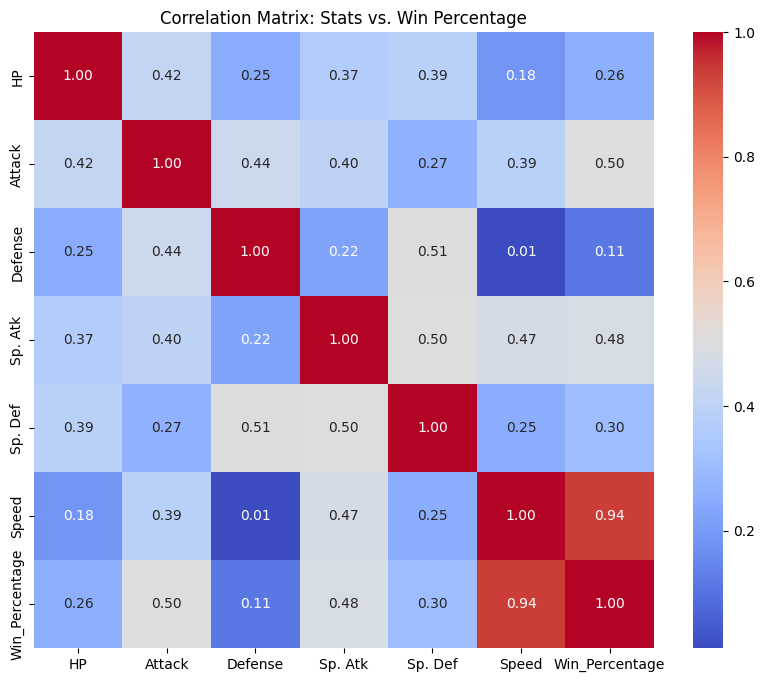

Top 10 Pokemon by Win Percentage:
                         Name  Win_Percentage  Speed  Attack
154           Mega Aerodactyl       98.449612    150     135
512                   Weavile       97.478992    125     120
703    Tornadus Therian Forme       96.800000    121     100
19              Mega Beedrill       96.638655    145     150
153                Aerodactyl       96.453901    130     105
476              Mega Lopunny       96.124031    135     136
726                  Greninja       96.062992    122      95
716  Meloetta Pirouette Forme       95.934959    128     128
164             Mega Mewtwo Y       95.200000    140     150
349             Mega Sharpedo       95.000000    105     140

Model Evaluation (Mean Absolute Error):
Linear Regression: 6.1531
Random Forest: 4.4744
Decision Tree: 5.4143


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Load datasets
# pokemon.csv contains stats for 800+ Pokemon
# combats.csv contains records of 50,000 battles
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

# Fix missing Name for Pokemon #62
# In the original dataset, the name for Primeape is missing
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

# Handle NaN values in 'Type 2'
# We replace missing second types with 'None'
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# Calculate Win Percentage
# Step A: Count total appearances for each Pokemon in combats
first_poke_counts = combats['First_pokemon'].value_counts()
second_poke_counts = combats['Second_pokemon'].value_counts()
total_battles = first_poke_counts.add(second_poke_counts, fill_value=0)

# Step B: Count total wins for each Pokemon
wins = combats['Winner'].value_counts()

# Step C: Combine into a win_stats DataFrame and calculate percentage
win_stats = pd.DataFrame({'Total_Battles': total_battles, 'Wins': wins}).fillna(0)
win_stats['Win_Percentage'] = (win_stats['Wins'] / win_stats['Total_Battles']) * 100

# Merge Win_Percentage back into the pokemon DataFrame using '#' as key
df = pokemon.merge(win_stats['Win_Percentage'], left_on='#', right_index=True)

# ==========================================
# 2. EXPLORATORY ANALYSIS & VISUALIZATION
# ==========================================

# Correlation Matrix
# Identifies which stats correlate most strongly with winning
numeric_df = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']]
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Stats vs. Win Percentage')
plt.show()

# Top 10 Pokemon Analysis
# Sorting by Win_Percentage to see the best performers
top_10 = df.sort_values(by='Win_Percentage', ascending=False).head(10)
print("Top 10 Pokemon by Win Percentage:")
print(top_10[['Name', 'Win_Percentage', 'Speed', 'Attack']])

# ==========================================
# 3. MACHINE LEARNING (Regression)
# ==========================================

# Define features (independent variables) and target (dependent variable)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = df[features]
y = df['Win_Percentage']

# Split dataset: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# Train and evaluate each model using Mean Absolute Error (MAE)
print("\nModel Evaluation (Mean Absolute Error):")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name}: {mae:.4f}")